Topics: Link prediction

*   Graph data preparation (Part 0)
*   Graph autoencoder (Part 1)
*   Variational graph autoencoder (Part 2)



# Part 0: Graph Data Preparation



Number of edges:  44


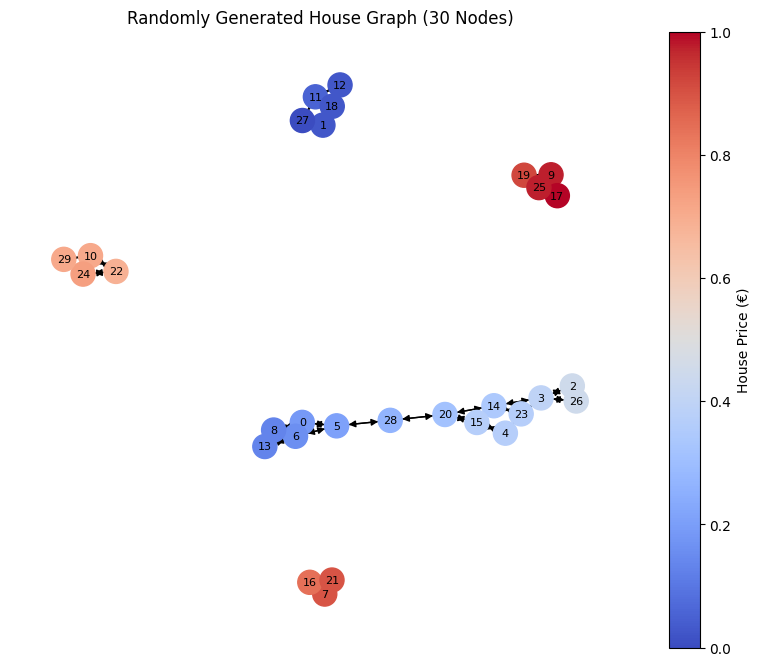

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
random.seed(42)

# Create an empty graph
G = nx.Graph()

# Add house nodes
num_nodes = 30
G.add_nodes_from(range(num_nodes))

# Initialize prices for the houses
for node in G.nodes():
    G.nodes[node]['price']  = random.randint(12, 50)

def similar_price(n1, n2):
  p1 = G.nodes[n1]['price']
  p2 = G.nodes[n2]['price']
  #print(f"node1 id: {n1}, price: {p1}; node2 id: {n2}, price: {p2}")
  # alternative: compute the normalized difference to make it more difficult
  # if abs(p1-p2)/(p1+p2) <= 10:
  if abs(p1-p2) <= 2:
    return True
  else:
    return False

# Add edges between houses of similar prices
# Connect each house (= node) to 1-2 other houses (randomly)
v = 0
for node in G.nodes():
    num_edges = random.randint(1, 2)
    neighbors = random.sample([n for n in G.nodes() if n != node and similar_price(node, n)], num_edges)
    #print(f"node: {node}, neighbors: {neighbors}")
    for neighbor in neighbors:
        G.add_edge(node, neighbor)
        v = v+1
print("Number of edges: ", v)

G = nx.to_directed(G)

# Visualize the graph
node_colors = [G.nodes[n]['price'] for n in G.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))

nx.draw(
    G,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Randomly Generated House Graph ({num_nodes} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

In [12]:
G.nodes(data=True)

NodeDataView({0: {'price': 19}, 1: {'price': 13}, 2: {'price': 29}, 3: {'price': 27}, 4: {'price': 26}, 5: {'price': 20}, 6: {'price': 18}, 7: {'price': 46}, 8: {'price': 17}, 9: {'price': 49}, 10: {'price': 39}, 11: {'price': 14}, 12: {'price': 13}, 13: {'price': 17}, 14: {'price': 25}, 15: {'price': 26}, 16: {'price': 44}, 17: {'price': 50}, 18: {'price': 13}, 19: {'price': 47}, 20: {'price': 24}, 21: {'price': 46}, 22: {'price': 38}, 23: {'price': 26}, 24: {'price': 40}, 25: {'price': 49}, 26: {'price': 29}, 27: {'price': 12}, 28: {'price': 22}, 29: {'price': 39}})

In [3]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.3 MB/s eta 0:00:00


In [13]:
import torch

training_data = [node[1]['price'] for node in list(G.nodes(data=True))]
print(training_data)

h_price = torch.tensor([item for item in training_data], dtype=torch.float).unsqueeze(1) # price value

edge_index = torch.tensor(list(G.edges), dtype=torch.long)
edge_index.t().contiguous()

from torch_geometric.data import Data

house_data = Data(x=h_price, edge_index=edge_index.t().contiguous())
house_data, house_data.num_nodes, house_data.num_edges, house_data.num_node_features, house_data.has_isolated_nodes(), house_data.has_self_loops(), house_data.is_directed()

[19, 13, 29, 27, 26, 20, 18, 46, 17, 49, 39, 14, 13, 17, 25, 26, 44, 50, 13, 47, 24, 46, 38, 26, 40, 49, 29, 12, 22, 39]


(Data(x=[30, 1], edge_index=[2, 74]), 30, 74, 1, False, False, False)

 Negative sampling

In [23]:
from torch_geometric.utils import negative_sampling
neg_edge_index = negative_sampling(
    edge_index=house_data.edge_index, #positive edges
    num_nodes=house_data.num_nodes, # number of nodes
    num_neg_samples=house_data.edge_index.size(1)) # number of neg_sample equal to number of pos_edges
neg_edge_index

tensor([[16, 20, 21, 23, 13, 11,  1, 17, 11, 17,  7, 12, 28,  9, 12,  9, 21,  9,
         19,  0, 18,  6,  3,  8, 25, 14, 17, 19, 26,  8, 24, 16, 25, 15, 27,  0,
          3, 10,  7, 14, 24,  8, 10, 23, 13, 19, 18, 12, 15, 26, 19, 11, 12, 24,
         16, 28,  8,  8,  4, 25,  6, 11,  4, 26, 18, 26, 24,  6,  6,  7, 17,  9,
         25, 20],
        [11,  3, 15, 17, 11, 26,  0, 13, 14,  6, 15, 16,  4,  3,  0, 26,  1, 22,
         18, 11,  7, 22,  0, 16, 12, 10,  7, 17, 22, 15, 11, 24,  3, 24, 29, 18,
          9, 12, 24,  8, 12, 18, 24, 12,  0, 15, 22,  4,  0,  9, 12, 20, 13, 23,
          0, 11, 26,  4,  8, 13, 24,  4,  7,  6, 27, 27, 10, 16, 23, 19,  2, 23,
         16, 24]])

In [24]:
y = torch.cat([house_data.edge_index, neg_edge_index])
y.shape, y

(torch.Size([4, 74]),
 tensor([[ 0,  0,  0,  1,  1,  2,  2,  3,  3,  3,  3,  4,  4,  5,  5,  5,  6,  6,
           6,  6,  7,  7,  8,  8,  8,  9,  9,  9, 10, 10, 11, 11, 11, 12, 13, 13,
          14, 14, 14, 14, 15, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 20, 20, 20,
          21, 21, 22, 22, 23, 23, 23, 24, 24, 25, 25, 25, 26, 26, 27, 27, 28, 28,
          29, 29],
         [ 8,  5,  6, 18, 27,  3, 26,  2, 14, 23, 26, 23, 15,  0, 28,  6,  0,  5,
           8, 13, 21, 16,  0, 13,  6, 25, 17, 19, 22, 29, 18, 12, 27, 11,  8,  6,
           3, 20, 15, 23,  4, 14, 20,  7, 21,  9, 25,  1, 11, 25,  9, 14, 15, 28,
           7, 16, 10, 24,  4, 14,  3, 22, 29,  9, 19, 17,  3,  2, 11,  1,  5, 20,
          24, 10],
         [16, 20, 21, 23, 13, 11,  1, 17, 11, 17,  7, 12, 28,  9, 12,  9, 21,  9,
          19,  0, 18,  6,  3,  8, 25, 14, 17, 19, 26,  8, 24, 16, 25, 15, 27,  0,
           3, 10,  7, 14, 24,  8, 10, 23, 13, 19, 18, 12, 15, 26, 19, 11, 12, 24,
          16, 28,  8,  8,  4, 25,  6, 

Loading tensorboard

In [25]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [41]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

# Part 1: Graph Autoencoder

## GAE - training and testing

In [32]:
# Adapted and extended from https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py
# and https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/nn/models/autoencoder.html#InnerProductDecoder.forward

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling


if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

transform = T.Compose([
    T.ToDevice(device),
    T.RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=False, add_negative_train_samples=False)])

# select a subset of the graph  for training/testing/validation purposes
# the number of nodes does not change
# a subset of the number of edges is taken for testing: edge_label contains both positive and negative examples of edges
# while edge_label_index contains the indices of these positive and negative edges
train_data, val_data, test_data = transform(house_data)
print("Original data:", house_data)
print("Training data: ", train_data, "\nValidation data: ", val_data, "\nTest data: ",  test_data)
print("Training labels ", train_data.edge_label, "\nValidation labels: ", val_data.edge_label, "\nTest labels: ",  test_data.edge_label)

class GAE(torch.nn.Module): # joint structure–feature autoencoder
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

        self.mlp_adj = nn.Sequential(
            nn.Linear(2 * in_channels, 10), # without raw feature: nn.Linear(2 * in_channels, 10); with raw features: nn.Linear(2 * 2 * in_channels, 10),
            nn.ReLU(),
            nn.Linear(10, 1))

        self.mlp_feat = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Linear(100, 1))

    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        return h

    def decode_structure_via_inner_product(self, h, edge_label_index):
        # inner product decoder: use pairwise similarity between two node features to predict edges
        src, dst = edge_label_index # 120, 120 because we have 2*60 positions for starting nodes (positive/negative) and 2*60 positions for end nodes (positive/negative)
        logits = (h[src] * h[dst]).sum(dim=-1)
        return logits

    def decode_structure_via_mlp(self, h, edge_label_index):
        # use a learnable function in the process of computing scores for the likelihood of edges
        src, dst = edge_label_index
        hi = h[src] # advanced indexing in pytorch => for each entry in src, lookup the the corresponding value of h
        hj = h[dst] # advanced indexing in pytorch => for each entry in dst, lookup the the corresponding value of h

        edge_features = torch.cat([hi, hj], dim=-1)

        #print("h-", h.shape, "src-", src.shape, "dst-", dst.shape, "hi-", hi.shape, "hj-", hj.shape, "edgefeatures-", edge_features.shape)
        logits = self.mlp_adj(edge_features)

        return logits

    def decode_structure_via_raw_features_and_mlp(self, h, x, edge_label_index):
        # include the raw features in the mlp decoder
        src, dst = edge_label_index

        hi = h[src]
        hj = h[dst]
        xi = x[src]
        xj = x[dst]

        edge_features = torch.cat([hi, hj, xi, xj], dim=-1)

        logits = self.mlp_adj(edge_features)

        return logits

    def decode_features(self, h):
        return self.mlp_feat(h)

model = GAE(1, 10, 1).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

mse = torch.nn.MSELoss() # feature reconstruction

bce = torch.nn.BCEWithLogitsLoss() # structure reconstruction

def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index)

    # We perform a new round of negative sampling for every training epoch:
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1), method='sparse')

    edge_label_index = torch.cat(
        [train_data.edge_label_index, neg_edge_index],
        dim=-1)
   # print("-----", torch.cat([train_data.edge_label_index, neg_edge_index]).shape) # [4, 60]
   # print("-----", torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1).shape) # [2, 120] start of the edge in a vector, end in a vector

    edge_label = torch.cat([
        train_data.edge_label,
        train_data.edge_label.new_zeros(neg_edge_index.size(1))
    ], dim=0)


    # structure reconstruction: the latent representation should preserve patterns of structural connections
    # node that are connected in the original graph are closer in the latent space
    #out = model.decode_structure_via_inner_product(z, edge_label_index).view(-1)
    out = model.decode_structure_via_mlp(z, edge_label_index).view(-1)
    #out = model.decode_structure_via_raw_features_and_mlp(z, train_data.x, edge_label_index).view(-1)
    loss_adj = bce(out, edge_label)

    # feature reconstruction: the latent representation should preserve the essential information in the node features
    # node that have similar attributes are closer in the latent space
    x_hat = model.decode_features(z)
    loss_feat = mse(train_data.x, x_hat)

    loss = loss_adj + loss_feat

    loss.backward()
    optimizer.step()
    return loss


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    #out = model.decode_structure_via_inner_product(z, data.edge_label_index)
    out = model.decode_structure_via_mlp(z, data.edge_label_index)
    #out = model.decode_structure_via_raw_features_and_mlp(z, train_data.x, data.edge_label_index)

    return roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())

n_epochs = 700 #1 #700
best_val_auc = final_test_auc = best_epoch = 0
for epoch in range(n_epochs):
    loss = train()

    val_auc = test(val_data)
    test_auc = test(test_data)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        final_test_auc = test_auc
        best_epoch = epoch

    if (epoch) % 10 == 0 or epoch == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}, Test: {test_auc:.4f}')

    writer.add_scalar("loss/gae", loss, epoch)
    writer.add_scalar("val-auc/gae", val_auc, epoch)
    writer.add_scalar("test-auc/gae", test_auc, epoch)

print(f'Best val auc: {best_val_auc:.4f}; from epoch: {best_epoch}; corresponding test auc: {final_test_auc:.4f}')

Original data: Data(x=[30, 1], edge_index=[2, 74])
Training data:  Data(x=[30, 1], edge_index=[2, 60], edge_label=[60], edge_label_index=[2, 60]) 
Validation data:  Data(x=[30, 1], edge_index=[2, 60], edge_label=[14], edge_label_index=[2, 14]) 
Test data:  Data(x=[30, 1], edge_index=[2, 67], edge_label=[14], edge_label_index=[2, 14])
Training labels  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1.]) 
Validation labels:  tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.]) 
Test labels:  tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.])
Epoch: 000, Loss: 884.0519, Val: 0.5714, Test: 0.4490
Epoch: 010, Loss: 13.7765, Val: 0.8367, Test: 0.8367
Epoch: 020, Loss: 15.2243, Val: 0.8980, Test: 1.0000
Epoch: 030, Loss: 13.2475, Val: 0.9592, Test: 0.

## Visualization of the training results via Tensorboard

In [29]:
writer.flush()
#writer.close()
# see https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/tensorboard_with_pytorch.ipynb

In [41]:
!kill 16752

In [ ]:
%tensorboard --logdir runs

## Visualizing the results of the reconstruction

orig_adj: torch.Size([2, 14]), content: tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.])
adj_recon: torch.Size([14]), content: tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0.])
Accuracy at threshold t = 0.5 is 0.8571428656578064
Number of original edges:  7
Number of reconstructed edges:  9


<Figure size 640x480 with 0 Axes>

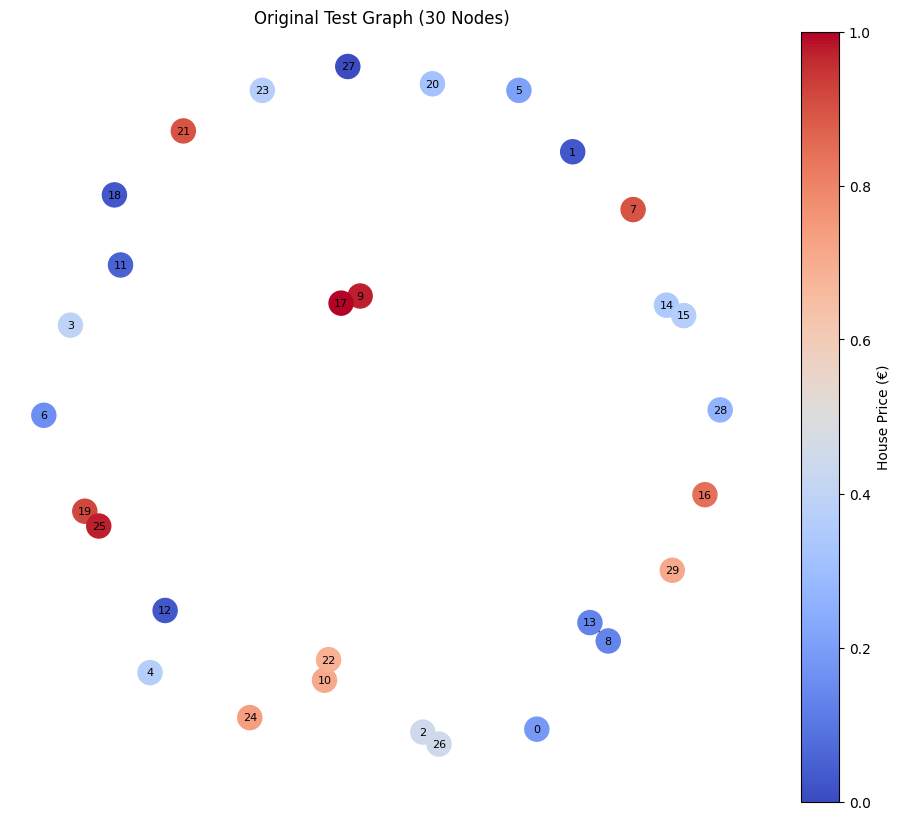

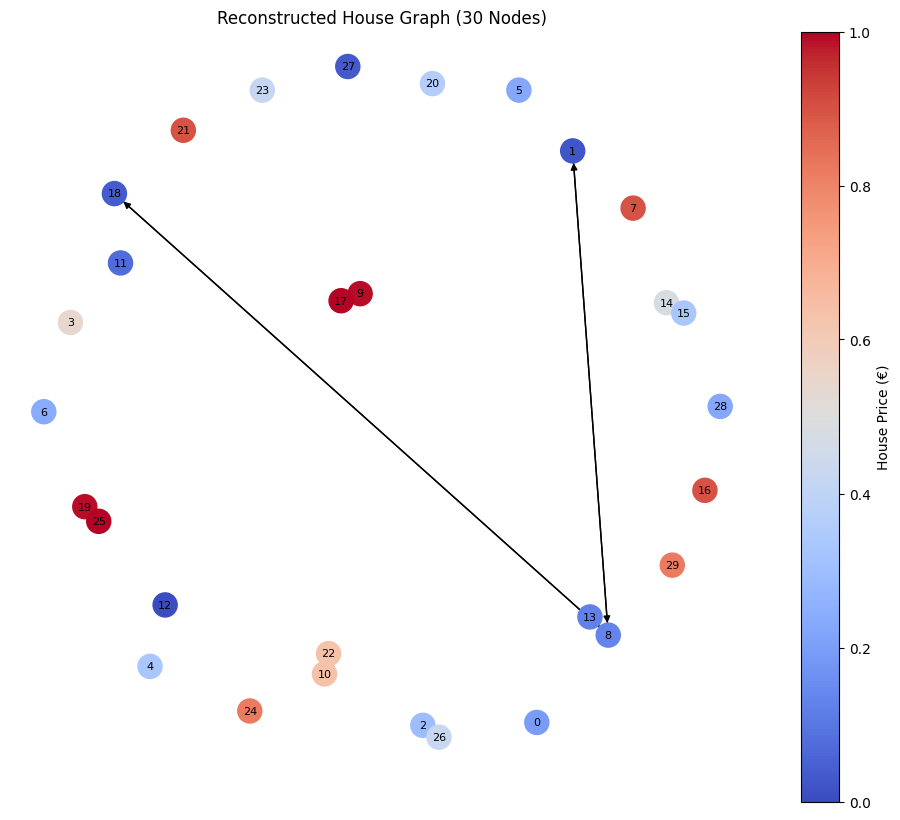

In [35]:
# visualizing the edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.utils import to_dense_adj
from torch_geometric.utils import to_networkx
from scipy.sparse import coo_array

# clear the figure (= previous graph)
plt.clf()

model.eval()
# get embeddings, reconstructed links and reconstructed prices
z = model.encode(test_data.x, test_data.edge_index)
#print("Embedding: ", z, ", shape: ", z.shape)

prices_reconstructed = model.decode_features(z).detach().numpy()

logits_adj = model.decode_structure_via_mlp(z, test_data.edge_label_index).view(-1)
#logits_adj = model.decode_structure_via_raw_features_and_mlp(z, test_data.x, test_data.edge_label_index).view(-1)
probs_adj = torch.sigmoid(logits_adj)

threshold = 0.5
adj_matrix_reconstructed = (probs_adj > threshold).float()
print(f"orig_adj: {test_data.edge_label_index.shape}, content: {test_data.edge_label}")
print(f"adj_recon: {adj_matrix_reconstructed.shape}, content: {adj_matrix_reconstructed}")

matches = (test_data.edge_label == adj_matrix_reconstructed)
print(f"Accuracy at threshold t = {threshold} is {matches.sum()/test_data.edge_label.size(0)}")


### test graph - create and populate the test graph
G_test = nx.Graph()
num_nodes = test_data.x.size(0) # the test graph has 30 nodes as well, just less edges than those we started with
for i in range(num_nodes):
    G_test.add_node(i, price=test_data.x[i].item()) # add features to nodes

orig_edge_index = test_data.edge_label_index
v = 0
for (src, dst), label in zip(orig_edge_index.t().tolist(), test_data.edge_label.tolist()):
    if label == 1:
     G_test.add_edge(src, dst) # add edges
     #print(f"-src: {src}, dst: {dst}, label: {label}")
     v = v+1
print("Number of original edges: ", v)

G_test = nx.to_directed(G_test)


### reconstructed graph - create and populate the reconstructed graph
G_recon = nx.Graph()
G_recon.add_nodes_from(range(num_nodes))

# add reconstructed prices for the houses
for node in G_recon.nodes():
    G_recon.nodes[node]['price'] = prices_reconstructed[node][0].item()

# create edge for nodes that are connected according to the adjacency matrix
u = 0
for (src, dst), label in zip(orig_edge_index.t().tolist(), adj_matrix_reconstructed.tolist()):
   if label == 1:
      G_recon.add_edge(src, dst) # add reconstructed edges
      #print(f"---src: {src}, dst: {dst}, label: {label}")
      u = u+1
print("Number of reconstructed edges: ", u)

G_recon = nx.to_directed(G_recon)


node_colors = [G_test.nodes[n]['price'] for n in G_test.nodes()]
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_test, seed=10)

nx.draw(
    G_test,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Original Test Graph ({G_test.number_of_nodes()} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

# Visualize the reconstructed graph
node_colors = [G_recon.nodes[n]['price'] for n in G_recon.nodes()]
fig, ax = plt.subplots(figsize=(12, 10))

nx.draw(
    G_recon,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Reconstructed House Graph ({G_recon.number_of_nodes()} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

[(0, {'price': 19.0}), (1, {'price': 13.0}), (2, {'price': 29.0}), (3, {'price': 27.0}), (4, {'price': 26.0}), (5, {'price': 20.0}), (6, {'price': 18.0}), (7, {'price': 46.0}), (8, {'price': 17.0}), (9, {'price': 49.0}), (10, {'price': 39.0}), (11, {'price': 14.0}), (12, {'price': 13.0}), (13, {'price': 17.0}), (14, {'price': 25.0}), (15, {'price': 26.0}), (16, {'price': 44.0}), (17, {'price': 50.0}), (18, {'price': 13.0}), (19, {'price': 47.0}), (20, {'price': 24.0}), (21, {'price': 46.0}), (22, {'price': 38.0}), (23, {'price': 26.0}), (24, {'price': 40.0}), (25, {'price': 49.0}), (26, {'price': 29.0}), (27, {'price': 12.0}), (28, {'price': 22.0}), (29, {'price': 39.0})]
[(0, {'price': 19.67198944091797}), (1, {'price': 13.965543746948242}), (2, {'price': 23.024372100830078}), (3, {'price': 31.157176971435547}), (4, {'price': 24.178184509277344}), (5, {'price': 20.771265029907227}), (6, {'price': 21.027753829956055}), (7, {'price': 43.187530517578125}), (8, {'price': 17.57077407836914

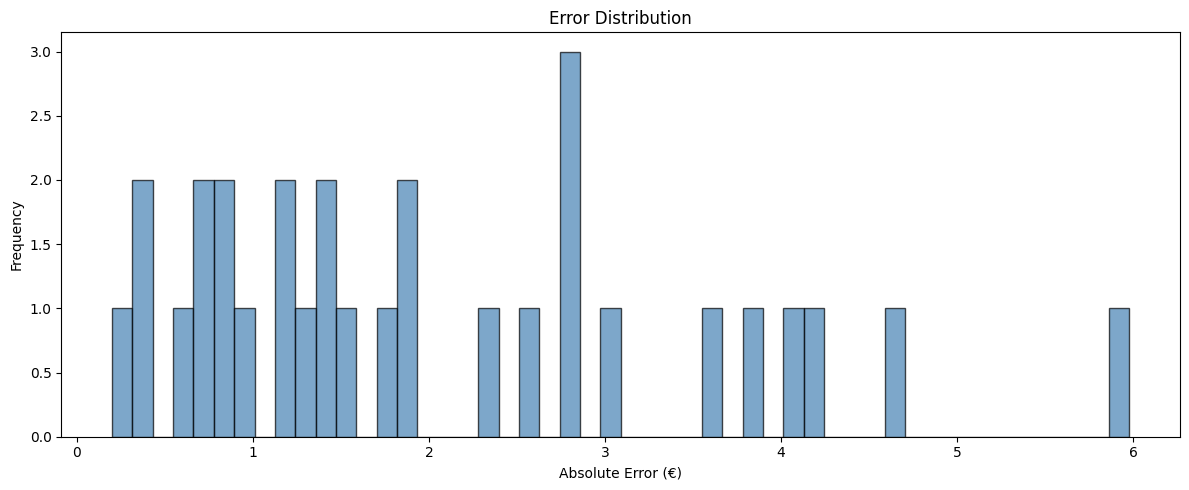

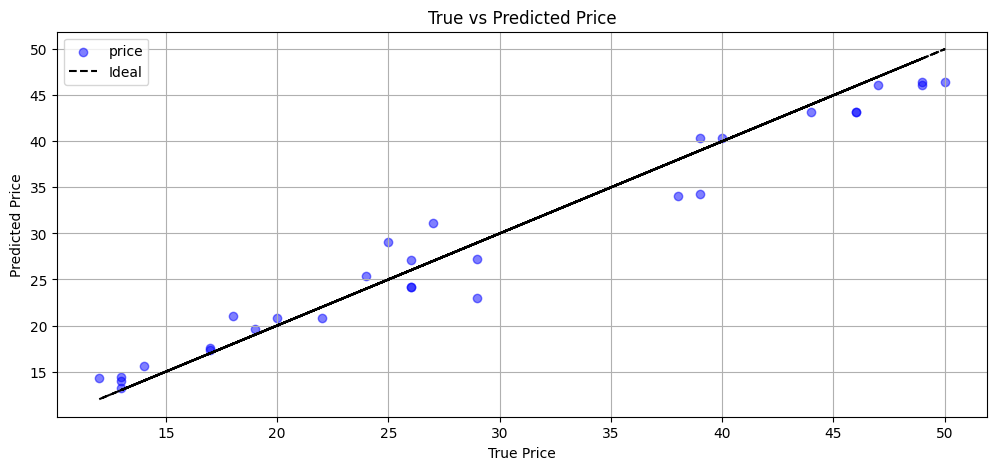

In [36]:
# visualizing the features
print(G_test.nodes(data=True))
print(G_recon.nodes(data=True))

true_price = nx.get_node_attributes(G_test, 'price')
pred_price = nx.get_node_attributes(G_recon, 'price')

error_dict = {}

for key in pred_price.keys():
    error_dict[key] = np.abs(pred_price[key] - true_price.get(key, 0)).item()

print(f"Mean price error: {np.mean(list(error_dict.values())):.4f}")

# histograms of errors
plt.figure(figsize=(12, 5))
plt.hist(list(error_dict.values()), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Error Distribution')
plt.xlabel('Absolute Error (€)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# scatter plot of true vs predicted
plt.figure(figsize=(12, 5))
plt.scatter(list(true_price.values()), list(pred_price.values()), alpha=0.5, label='price', c='blue')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.plot(list(true_price.values()), list(true_price.values()), 'k--', label="Ideal")
plt.legend()
plt.title("True vs Predicted Price")
plt.grid(True)

## Graph comparison

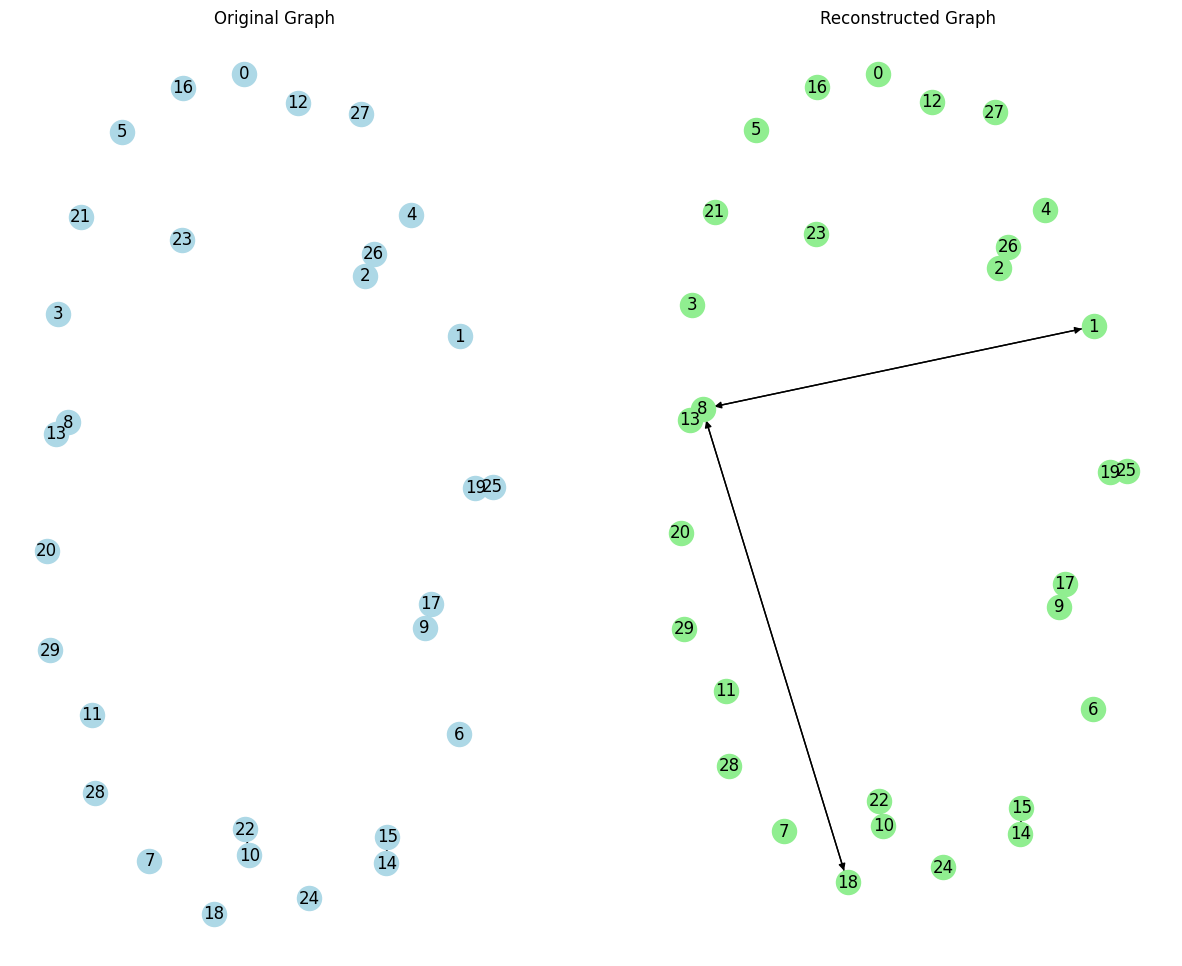

In [37]:
import matplotlib.pyplot as plt

def visualize_graphs(G_orig, G_recon):
    plt.figure(figsize=(15, 12))

    # Same layout for comparison
    pos = nx.spring_layout(G_orig, seed=42)

    plt.subplot(1, 2, 1)
    nx.draw(G_orig, pos, with_labels=True, node_color="lightblue")
    plt.title("Original Graph")

    plt.subplot(1, 2, 2)
    nx.draw(G_recon, pos, with_labels=True, node_color="lightgreen")
    plt.title("Reconstructed Graph")

    plt.show()

visualize_graphs(G_test, G_recon)

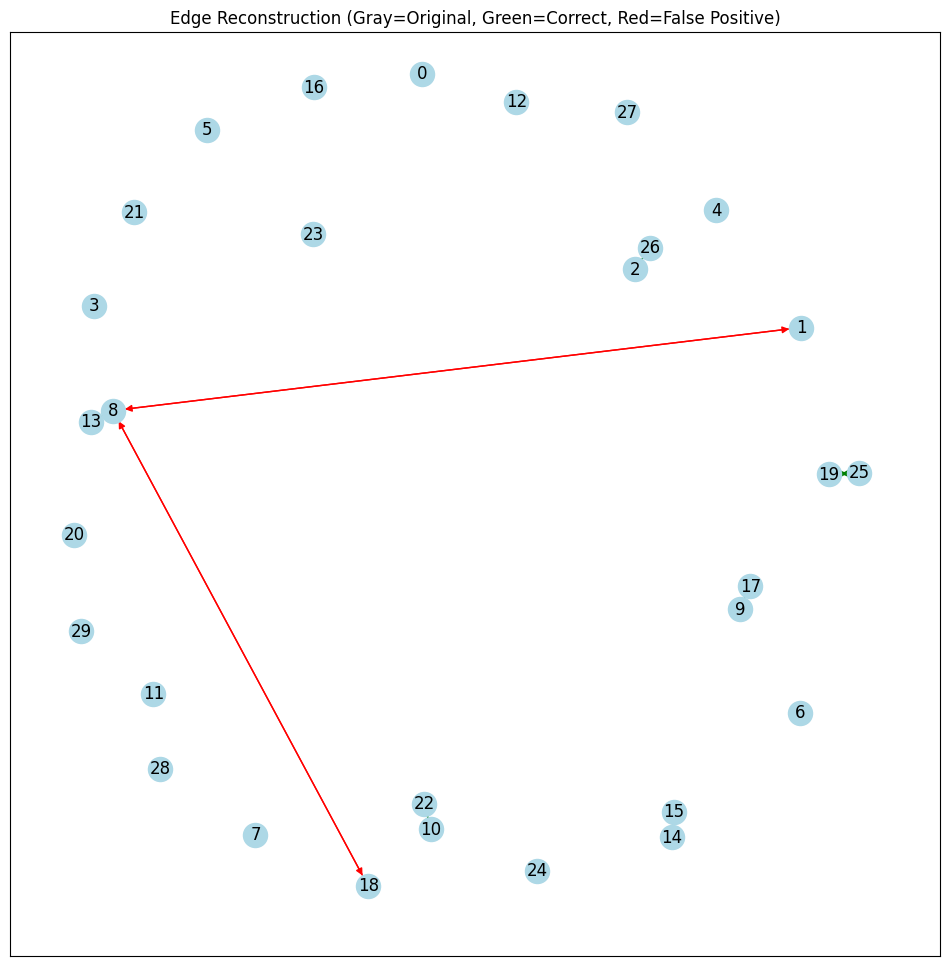

In [38]:
def plot_edge_diff(G_orig, G_recon):
    pos = nx.spring_layout(G_orig, seed=42)

    plt.figure(figsize=(12, 12))

    # Original edges
    nx.draw_networkx_edges(G_orig, pos, edge_color="gray", alpha=0.3)

    # Correct reconstructions
    common = set(G_orig.edges()) & set(G_recon.edges())
    nx.draw_networkx_edges(G_recon, pos, edgelist=common, edge_color="green")

    # False positives
    false_pos = set(G_recon.edges()) - set(G_orig.edges())
    nx.draw_networkx_edges(G_recon, pos, edgelist=false_pos, edge_color="red")

    nx.draw_networkx_nodes(G_orig, pos, node_color="lightblue")
    nx.draw_networkx_labels(G_orig, pos)

    plt.title("Edge Reconstruction (Gray=Original, Green=Correct, Red=False Positive)")
    plt.show()

plot_edge_diff(G_test, G_recon)

# Part 2: Variational Graph Autoencoder

## VGAE - training and testing

In [39]:
# adapted from
# https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/nn/models/autoencoder.html#InnerProductDecoder.forward
# https://github.com/vmasrani/gae_in_pytorch/blob/master/models.py
# https://github.com/Flawless1202/VGAE_pyG/blob/master/model.py


import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling


if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

transform = T.Compose([
    T.ToDevice(device),
    T.RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=False, add_negative_train_samples=False)])

# select a subset of the graph  for training/testing/validation purposes
# the number of nodes does not change
# a subset of the number of edges is taken for testing: edge_label contains both positive and negative examples of edges
# while edge_label_index contains the indices of these positive and negative edges
train_data, val_data, test_data = transform(house_data)
print("Original data:", house_data)
print("Training data: ", train_data, "\nValidation data: ", val_data, "\nTest data: ",  test_data)
print("Training labels ", train_data.edge_label, "\nValidation labels: ", val_data.edge_label, "\nTest labels: ",  test_data.edge_label)

class VGAE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.gcn_shared1 = GCNConv(in_channels, hidden_channels)
        self.gcn_shared2 = GCNConv(hidden_channels, hidden_channels)

        self.gcn_mu = GCNConv(hidden_channels, out_channels)
        self.gcn_logvar = GCNConv(hidden_channels, out_channels)

        self.mlp_adj = nn.Sequential(
            nn.Linear(2 * in_channels, 10), # nn.Linear(2 * 2 * in_channels, 10), nn.Linear(2 * in_channels, 10)
            nn.ReLU(),
            nn.Linear(10, 1))

        self.mlp_feat = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Linear(100, 1))

    def encode(self, x, edge_index):
        # from https://github.com/zfjsail/gae-pytorch/blob/master/gae/model.py
        h = self.gcn_shared1(x, edge_index)
        h = h.relu()
        h = self.gcn_shared2(h, edge_index)
        h = h.relu()

        mu = self.gcn_mu(h, edge_index)
        logvar = self.gcn_logvar(h, edge_index)

        z = self.reparameterize(mu, logvar)

        return z, mu, logvar

    def decode_structure_via_mlp(self, h, edge_label_index):

        src, dst = edge_label_index

        hi = h[src]
        hj = h[dst]

        edge_features = torch.cat([hi, hj], dim=-1)
        logits_adj = self.mlp_adj(edge_features)

        return logits_adj


    def decode_structure_via_raw_features_and_mlp(self, h, x, edge_label_index):

        src, dst = edge_label_index

        hi = h[src]
        hj = h[dst]
        xi = x[src]
        xj = x[dst]

        edge_features = torch.cat([hi, hj, xi, xj], dim=-1)

        logits_adj = self.mlp_adj(edge_features)

        return logits_adj


    def decode_features(self, z):

        return self.mlp_feat(z)


    def reparameterize(self, mu, logvar):
        # from https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/nn/models/autoencoder.html#VGAE
        if self.training:
            var = torch.exp(logvar)
            epsilon = torch.randn_like(var)
            z = mu + var * epsilon
            return z
        else:
            return mu # only return mu when we are doing testing


vgae_model = VGAE(1, 10, 1).to(device)
optimizer = torch.optim.Adam(params=vgae_model.parameters(), lr=0.01)

bce = torch.nn.BCEWithLogitsLoss()
mse = torch.nn.MSELoss()


def train():
    vgae_model.train()
    optimizer.zero_grad()

    z, mu, logvar = vgae_model.encode(train_data.x, train_data.edge_index)

    # We perform a new round of negative sampling for every training epoch:
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1), method='sparse')

    edge_label_index = torch.cat(
        [train_data.edge_label_index, neg_edge_index],
        dim=-1,
    )

    edge_label = torch.cat([
        train_data.edge_label,
        train_data.edge_label.new_zeros(neg_edge_index.size(1))
    ], dim=0)

    # structure reconstruction
    out = vgae_model.decode_structure_via_mlp(z, edge_label_index).view(-1)
    #out = vgae_model.decode_structure_via_raw_features_and_mlp(z, train_data.x, edge_label_index).view(-1)
    loss_adj = bce(out, edge_label)

    # feature reconstruction
    x_hat = vgae_model.decode_features(z)
    loss_feat = mse(train_data.x, x_hat)

    # kl divergence
    # for loss, see also https://github.com/zfjsail/gae-pytorch/blob/master/gae/optimizer.py#L7 and
    # https://pytorch-geometric.readthedocs.io/en/2.7.0/_modules/torch_geometric/nn/models/autoencoder.html#VGAE.kl_loss
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    loss = loss_adj + loss_feat + kl_loss

    loss.backward()
    optimizer.step()
    return loss


@torch.no_grad()
def test(data):
    vgae_model.eval()
    z, mu, logvar = vgae_model.encode(data.x, data.edge_index)
    out = vgae_model.decode_structure_via_mlp(z, data.edge_label_index)
    #out = model.decode_structure_via_raw_features_and_mlp(z, data.x, data.edge_label_index)

    return roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())

n_epochs = 700 # 700    #700
best_val_auc = final_test_auc = best_epoch = 0
for epoch in range(n_epochs):
    loss = train()
    val_auc = test(val_data)
    test_auc = test(test_data)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        final_test_auc = test_auc
        best_epoch = epoch
    if (epoch) % 10 == 0 or epoch == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}, Test: {test_auc:.4f}')
    writer.add_scalar("loss/vgae", loss, epoch)
    writer.add_scalar("val-auc/vgae", val_auc, epoch)
    writer.add_scalar("test-auc/vgae", test_auc, epoch)

print(f'Best val auc: {best_val_auc:.4f}; from epoch: {best_epoch}; corresponding test auc: {final_test_auc:.4f}')

Original data: Data(x=[30, 1], edge_index=[2, 74])
Training data:  Data(x=[30, 1], edge_index=[2, 60], edge_label=[60], edge_label_index=[2, 60]) 
Validation data:  Data(x=[30, 1], edge_index=[2, 60], edge_label=[14], edge_label_index=[2, 14]) 
Test data:  Data(x=[30, 1], edge_index=[2, 67], edge_label=[14], edge_label_index=[2, 14])
Training labels  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1.]) 
Validation labels:  tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.]) 
Test labels:  tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.])
Epoch: 000, Loss: 1070.1632, Val: 0.3265, Test: 0.4490
Epoch: 010, Loss: 265.6290, Val: 0.4082, Test: 0.5102
Epoch: 020, Loss: 78.4272, Val: 0.4082, Test: 0.5102
Epoch: 030, Loss: 87.7015, Val: 0.4082, Test: 

## Visualization of the training results via Tensorboard

In [40]:
writer.flush()
#writer.close()
# see https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/tensorboard_with_pytorch.ipynb

In [45]:
!kill 19599

In [ ]:
%tensorboard --logdir runs

## Visualizing the results of the reconstruction

orig_adj: torch.Size([2, 14]), content: tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.])
adj_recon: torch.Size([14]), content: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])
Accuracy at threshold t = 0.5 is 0.8571428656578064
Number of original edges:  7
Number of reconstructed edges:  9


<Figure size 640x480 with 0 Axes>

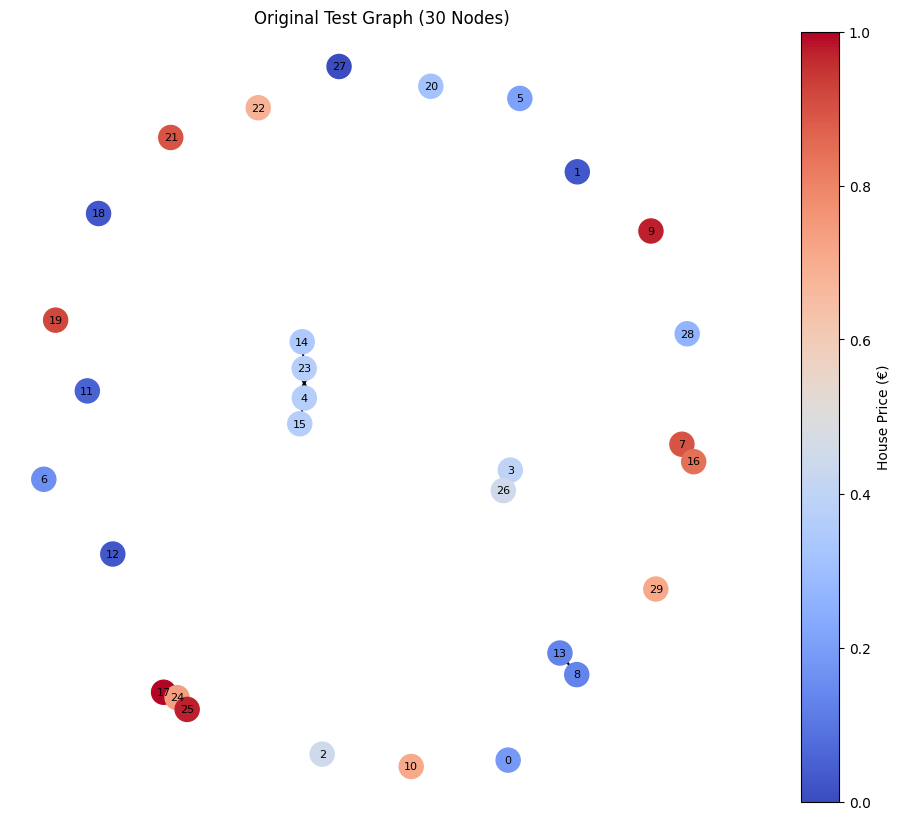

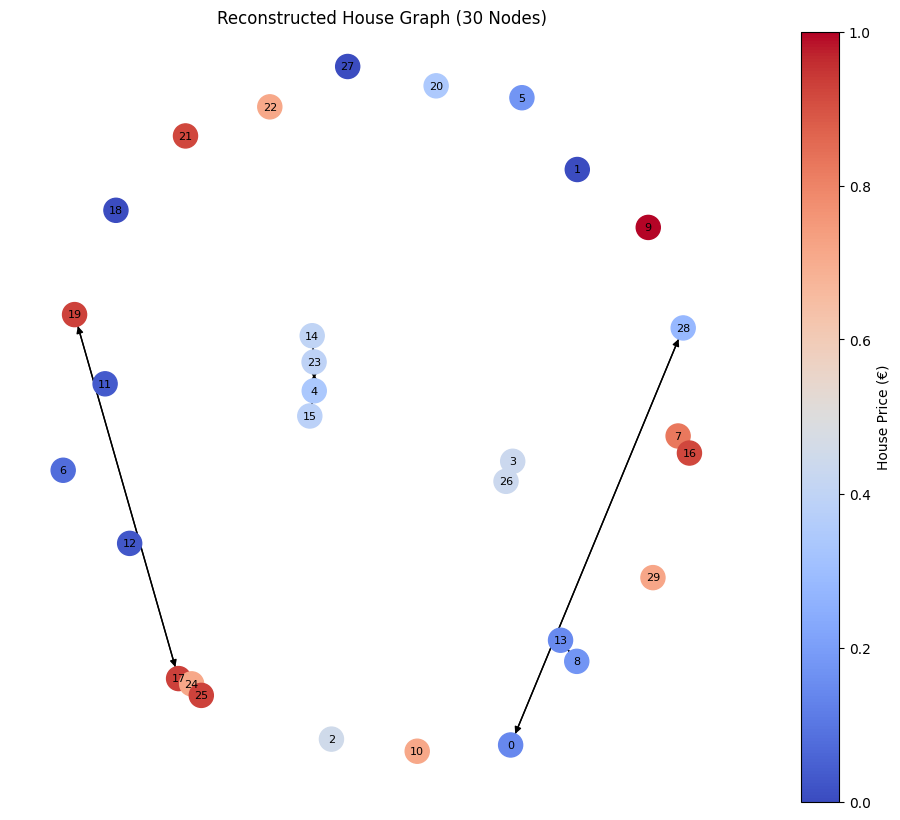

In [43]:
# visualizing the edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.utils import to_dense_adj
from torch_geometric.utils import to_networkx
from scipy.sparse import coo_array

# clear the figure (= previous graph)
plt.clf()

vgae_model.eval()

# get embeddings, reconstructed links and reconstructed prices
z, mu, logvar = vgae_model.encode(test_data.x, test_data.edge_index)

prices_reconstructed = vgae_model.decode_features(z).detach().numpy()

logits_adj = vgae_model.decode_structure_via_mlp(z, test_data.edge_label_index).view(-1)
#logits_adj = vgae_model.decode_structure_via_raw_features_and_mlp(z, test_data.x, test_data.edge_label_index).view(-1)
probs_adj = torch.sigmoid(logits_adj)

threshold = 0.5
adj_matrix_reconstructed = (probs_adj > threshold).float()
print(f"orig_adj: {test_data.edge_label_index.shape}, content: {test_data.edge_label}")
print(f"adj_recon: {adj_matrix_reconstructed.shape}, content: {adj_matrix_reconstructed}")

matches = (test_data.edge_label == adj_matrix_reconstructed)
print(f"Accuracy at threshold t = {threshold} is {matches.sum()/test_data.edge_label.size(0)}")


### test graph - create and populate the test graph
G_test = nx.Graph()
num_nodes = test_data.x.size(0) # the test graph has 30 nodes as well, just less edges than those we started with
for i in range(num_nodes):
    G_test.add_node(i, price=test_data.x[i].item()) # add features to nodes

orig_edge_index = test_data.edge_label_index
v = 0
for (src, dst), label in zip(orig_edge_index.t().tolist(), test_data.edge_label.tolist()):
    if label == 1:
     G_test.add_edge(src, dst) # add edges
     #print(f"-src: {src}, dst: {dst}, label: {label}")
     v = v+1
print("Number of original edges: ", v)

G_test = nx.to_directed(G_test)


### reconstructed graph - create and populate the reconstructed graph
G_recon = nx.Graph()
G_recon.add_nodes_from(range(num_nodes))

# add reconstructed prices for the houses
for node in G_recon.nodes():
    G_recon.nodes[node]['price'] = prices_reconstructed[node][0].item()

# create edge for nodes that are connected according to the adjacency matrix
u = 0
for (src, dst), label in zip(orig_edge_index.t().tolist(), adj_matrix_reconstructed.tolist()):
   if label == 1:
      G_recon.add_edge(src, dst) # add reconstructed edges
      #print(f"---src: {src}, dst: {dst}, label: {label}")
      u = u+1
print("Number of reconstructed edges: ", u)

G_recon = nx.to_directed(G_recon)


node_colors = [G_test.nodes[n]['price'] for n in G_test.nodes()]
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_test, seed=10)

nx.draw(
    G_test,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Original Test Graph ({G_test.number_of_nodes()} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

# Visualize the reconstructed graph
node_colors = [G_recon.nodes[n]['price'] for n in G_recon.nodes()]
fig, ax = plt.subplots(figsize=(12, 10))

nx.draw(
    G_recon,
    pos=pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Reconstructed House Graph ({G_recon.number_of_nodes()} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

[(0, {'price': 19.0}), (1, {'price': 13.0}), (2, {'price': 29.0}), (3, {'price': 27.0}), (4, {'price': 26.0}), (5, {'price': 20.0}), (6, {'price': 18.0}), (7, {'price': 46.0}), (8, {'price': 17.0}), (9, {'price': 49.0}), (10, {'price': 39.0}), (11, {'price': 14.0}), (12, {'price': 13.0}), (13, {'price': 17.0}), (14, {'price': 25.0}), (15, {'price': 26.0}), (16, {'price': 44.0}), (17, {'price': 50.0}), (18, {'price': 13.0}), (19, {'price': 47.0}), (20, {'price': 24.0}), (21, {'price': 46.0}), (22, {'price': 38.0}), (23, {'price': 26.0}), (24, {'price': 40.0}), (25, {'price': 49.0}), (26, {'price': 29.0}), (27, {'price': 12.0}), (28, {'price': 22.0}), (29, {'price': 39.0})]
[(0, {'price': 17.793701171875}), (1, {'price': 12.658385276794434}), (2, {'price': 29.090728759765625}), (3, {'price': 28.60889434814453}), (4, {'price': 24.97333526611328}), (5, {'price': 18.94268798828125}), (6, {'price': 15.454195976257324}), (7, {'price': 42.83462142944336}), (8, {'price': 19.061553955078125}), (

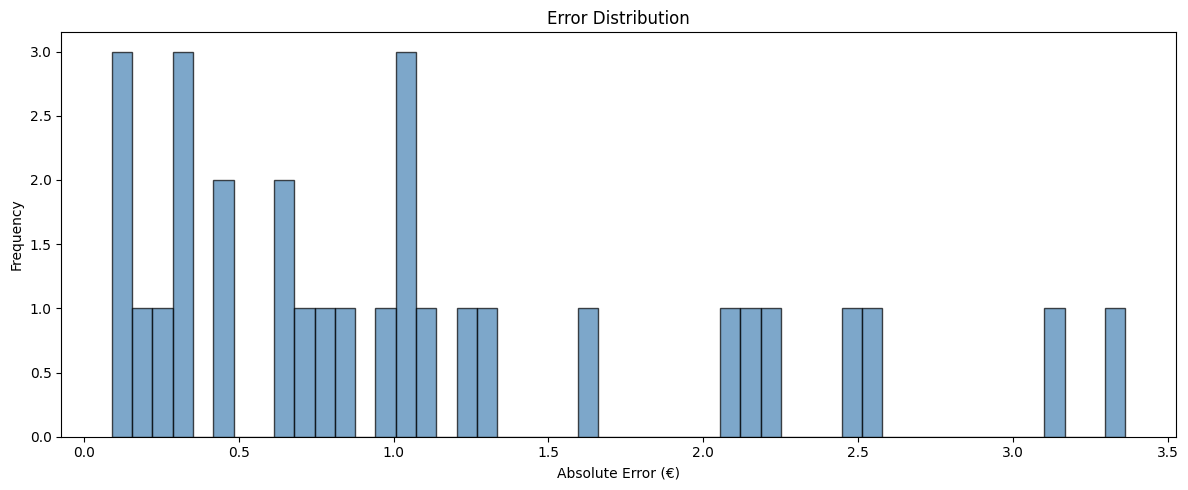

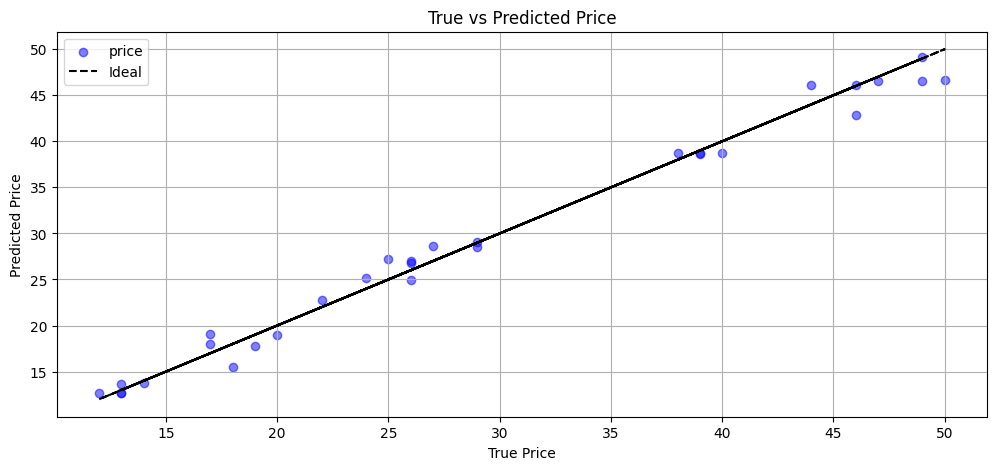

In [44]:
# visualizing the features
print(G_test.nodes(data=True))
print(G_recon.nodes(data=True))

true_price = nx.get_node_attributes(G_test, 'price')
pred_price = nx.get_node_attributes(G_recon, 'price')

error_dict = {}

for key in pred_price.keys():
    error_dict[key] = np.abs(pred_price[key] - true_price.get(key, 0)).item()

print(f"Mean price error: {np.mean(list(error_dict.values())):.4f}")

# histograms of errors
plt.figure(figsize=(12, 5))
plt.hist(list(error_dict.values()), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Error Distribution')
plt.xlabel('Absolute Error (€)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# scatter plot of true vs predicted
plt.figure(figsize=(12, 5))
plt.scatter(list(true_price.values()), list(pred_price.values()), alpha=0.5, label='price', c='blue')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.plot(list(true_price.values()), list(true_price.values()), 'k--', label="Ideal")
plt.legend()
plt.title("True vs Predicted Price")
plt.grid(True)

## Graph comparison

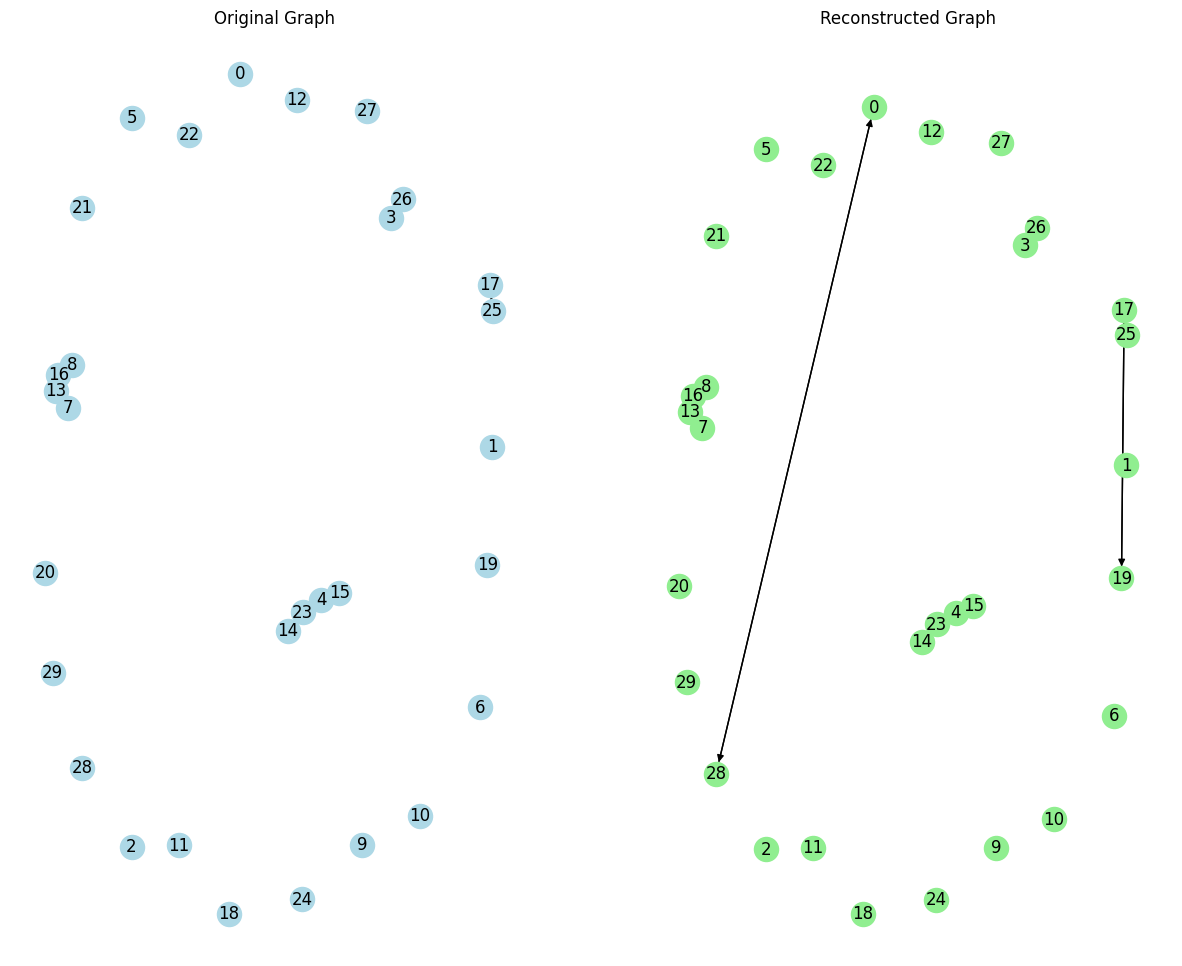

In [45]:
import matplotlib.pyplot as plt

def visualize_graphs(G_orig, G_recon):
    plt.figure(figsize=(15, 12))

    # Same layout for comparison
    pos = nx.spring_layout(G_orig, seed=42)

    plt.subplot(1, 2, 1)
    nx.draw(G_orig, pos, with_labels=True, node_color="lightblue")
    plt.title("Original Graph")

    plt.subplot(1, 2, 2)
    nx.draw(G_recon, pos, with_labels=True, node_color="lightgreen")
    plt.title("Reconstructed Graph")

    plt.show()

visualize_graphs(G_test, G_recon)

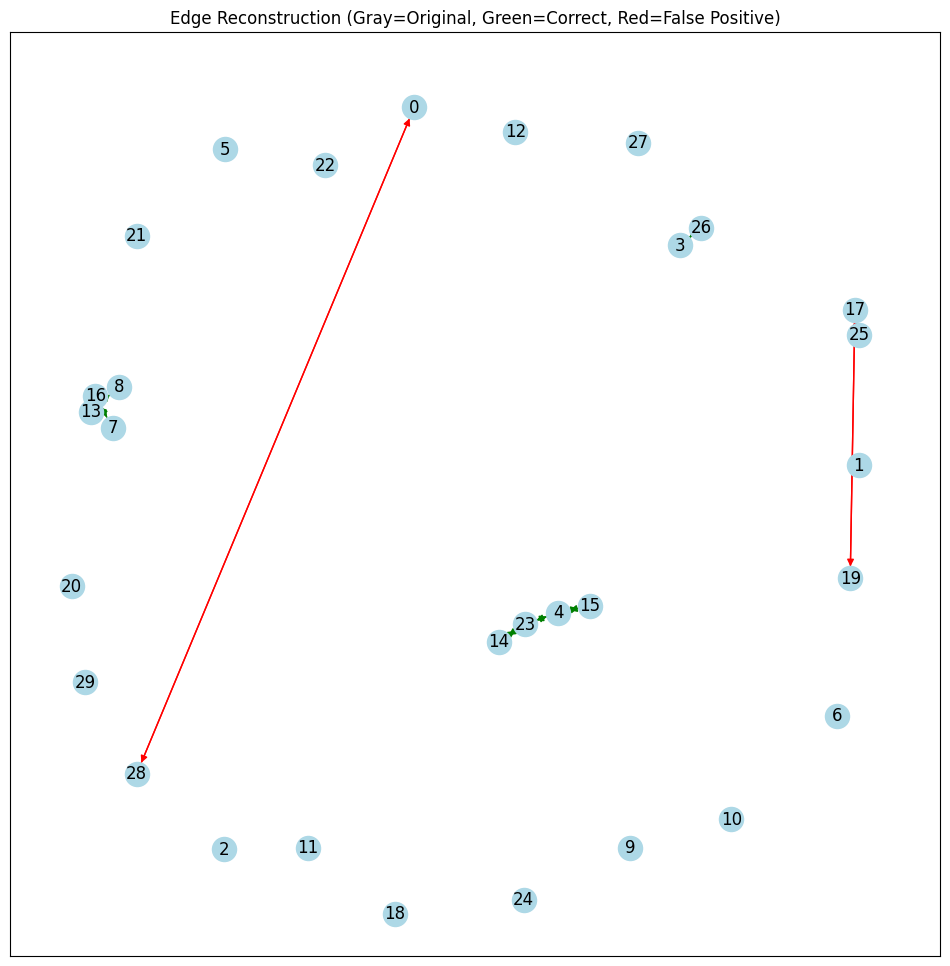

In [46]:
def plot_edge_diff(G_orig, G_recon):
    pos = nx.spring_layout(G_orig, seed=42)

    plt.figure(figsize=(12, 12))

    # Original edges
    nx.draw_networkx_edges(G_orig, pos, edge_color="gray", alpha=0.3)

    # Correct reconstructions
    common = set(G_orig.edges()) & set(G_recon.edges())
    nx.draw_networkx_edges(G_recon, pos, edgelist=common, edge_color="green")

    # False positives
    false_pos = set(G_recon.edges()) - set(G_orig.edges())
    nx.draw_networkx_edges(G_recon, pos, edgelist=false_pos, edge_color="red")

    nx.draw_networkx_nodes(G_orig, pos, node_color="lightblue")
    nx.draw_networkx_labels(G_orig, pos)

    plt.title("Edge Reconstruction (Gray=Original, Green=Correct, Red=False Positive)")
    plt.show()

plot_edge_diff(G_test, G_recon)

# Project work


*   EX01: Change the graph comparison code to visualize the price ranges as well
*   EX02: Test the function decode_structure_via_raw_features_and_mlp during training and check the impact on the results

